# Plant root characteristics: Prediction vs WinRHIZO

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy import stats

In [9]:
model_name = "unetr"
df_gt = pd.read_csv("data_info/MNHT_rootmorphology_GT.csv")
df_pred = pd.read_csv(f"data_info/prediction_{model_name}.csv")

# keep only the cores that are in both df_gt and df_pred
df_pred = df_pred[df_pred["soil_core"].isin(df_gt["label ID"])]
df_gt = df_gt[df_gt["label ID"].isin(df_pred["soil_core"])]

# sort df_pred by soil_core
df_pred = df_pred.sort_values(by="soil_core")
df_gt = df_gt.sort_values(by="label ID")

In [10]:
## Run only if you want to upload the calibration parameters

selcores = pd.read_csv("data_info/sel_cores.csv")["sel_cores"].values
df_gt = df_gt[df_gt["label ID"].isin(selcores)]
df_pred = df_pred[df_pred["soil_core"].isin(selcores)]

# Calibrating df_pred to df_gt
with open(f"data_info/calibration_params_{model_name}.json", "r") as f:
    calibration_params = json.load(f)

xfeat = calibration_params["xfeat"]
yfeat = calibration_params["yfeat"]
slope = calibration_params["slope"]
intercept = calibration_params["intercept"]
r = calibration_params["r"]
p = calibration_params["p"]
se = calibration_params["se"]

df_pred[yfeat] = slope * df_pred[yfeat] + intercept

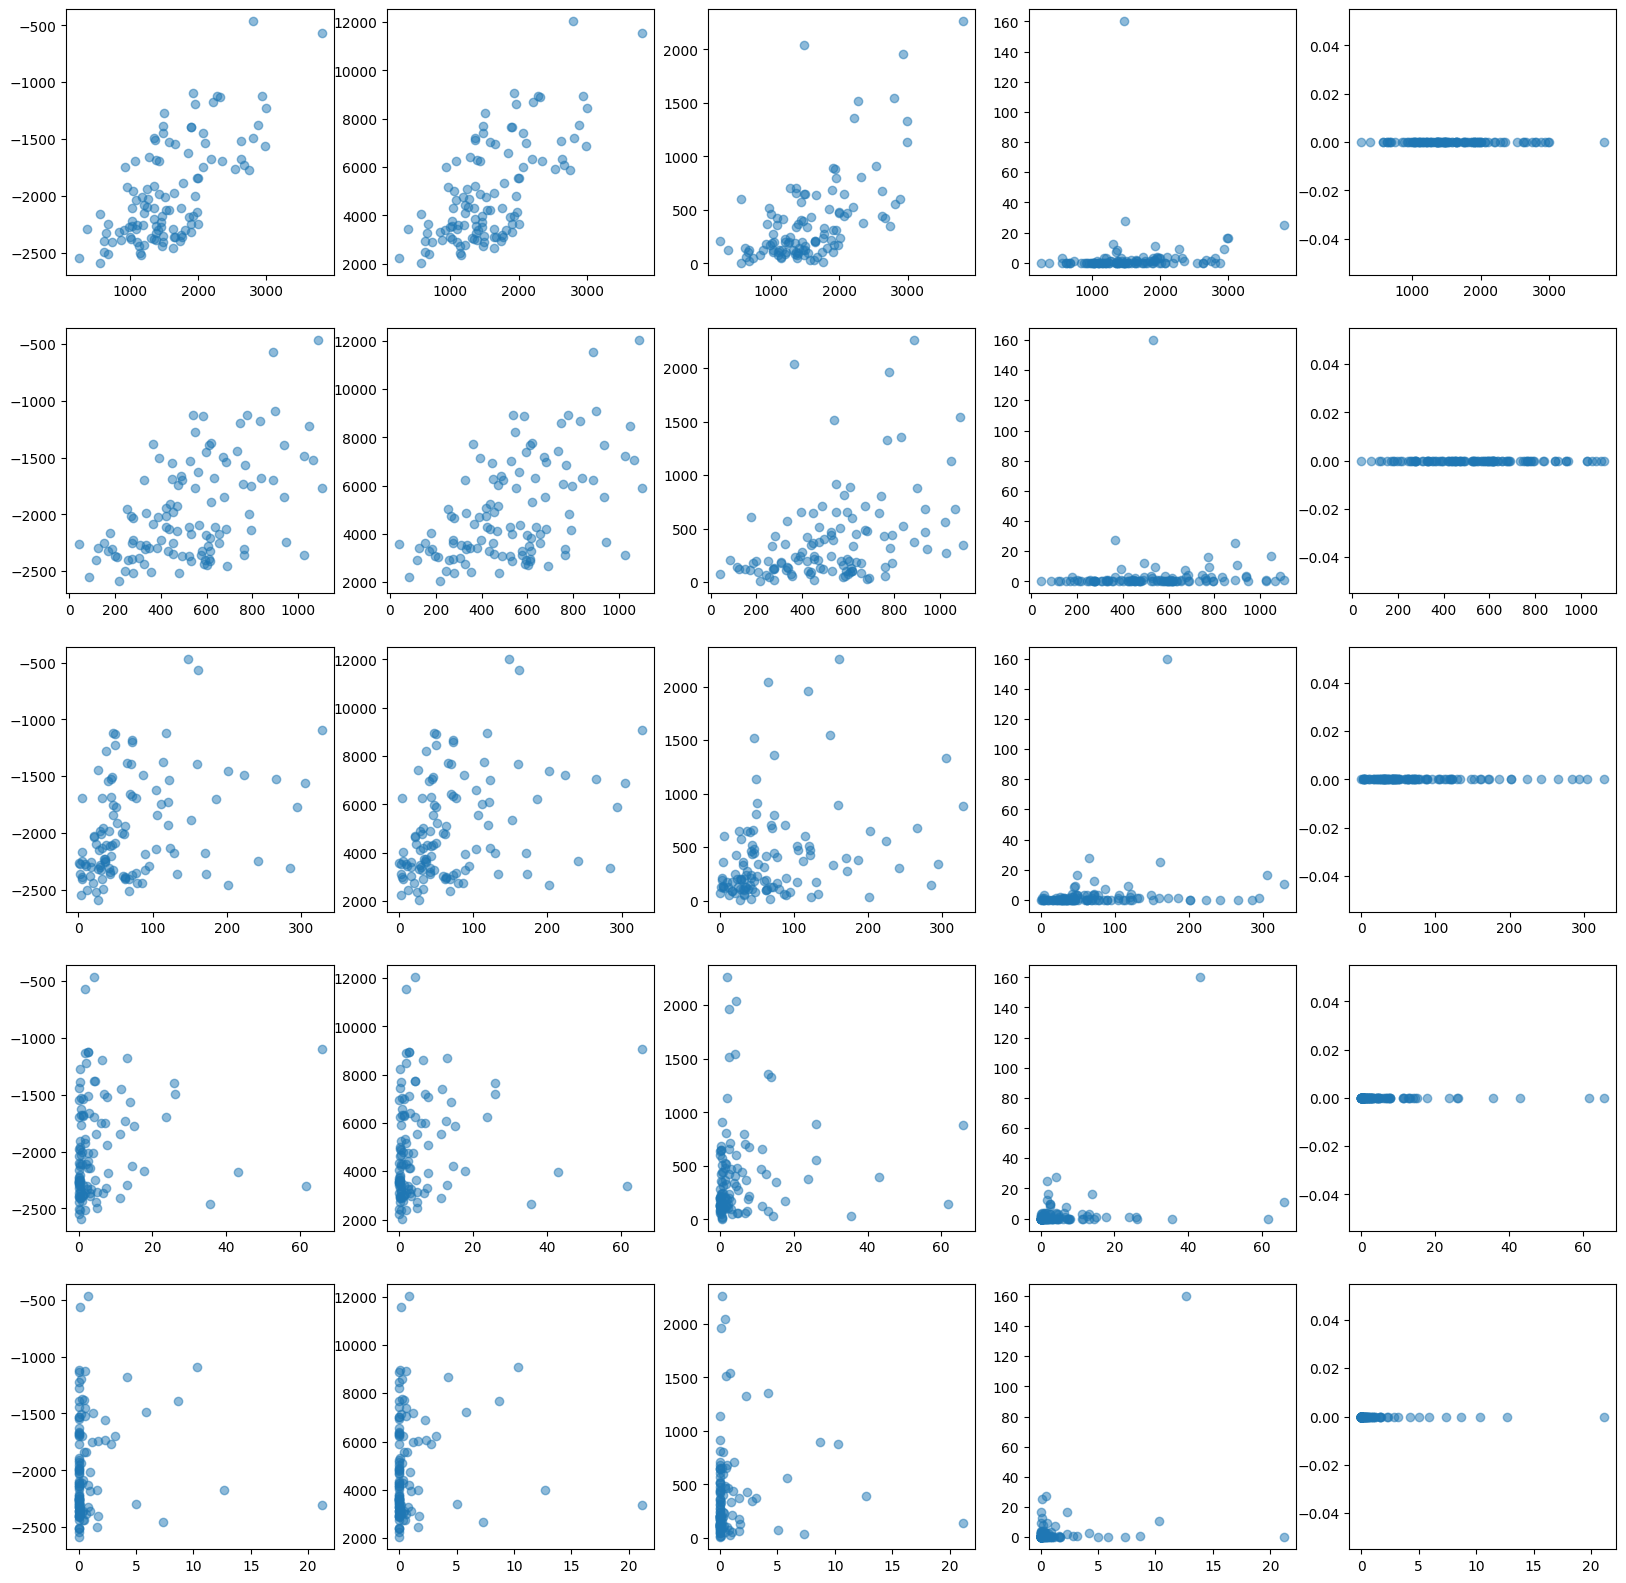

In [11]:
# df_gt[df_gt["label ID"].isin(df_pred["soil_core"])].reset_index(drop=True)

lfeat = ['L00', 'L10', 'L20', 'L30', 'L40']

plt.figure(figsize=(20, 20))

for i, xfeat in enumerate(lfeat):
    for j, yfeat in enumerate(lfeat):
        plt.subplot(len(lfeat), len(lfeat), i*len(lfeat) + j + 1)
        x = df_gt[df_gt["label ID"].isin(df_pred["soil_core"])][xfeat].values
        y = df_pred[yfeat].values
        plt.scatter(x, y, alpha=0.5)
        # plt.xlabel("WinRHIZO")
        # plt.ylabel("U-Net")
        # plt.title("Root length (cm) prediction")
plt.show()


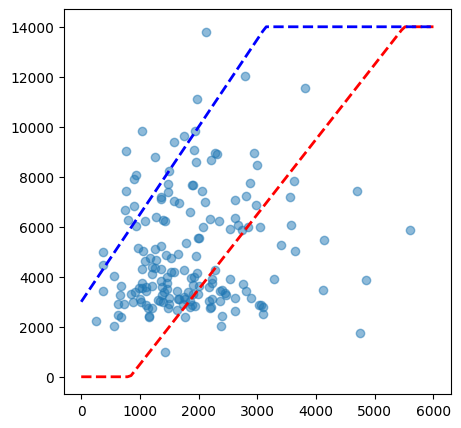

In [4]:
xl = np.linspace(0, 6000, 100)
m, b = 3.0, -2500
m2, b2 = 3.5, 3000
yl = m*xl+b
yl = np.clip(yl, 0, 14000)
yl2 = m2*xl+b2
yl2 = np.clip(yl2, 0, 14000)
xfeat = 'L00'
yfeat = 'L00'
plt.figure(figsize=(5, 5))
x = df_gt[df_gt["label ID"].isin(df_pred["soil_core"])][xfeat].values
y = df_pred[yfeat].values
plt.scatter(x, y, alpha=0.5)
plt.plot(xl, yl, 'r--', linewidth=2)
plt.plot(xl, yl2, 'b--', linewidth=2)

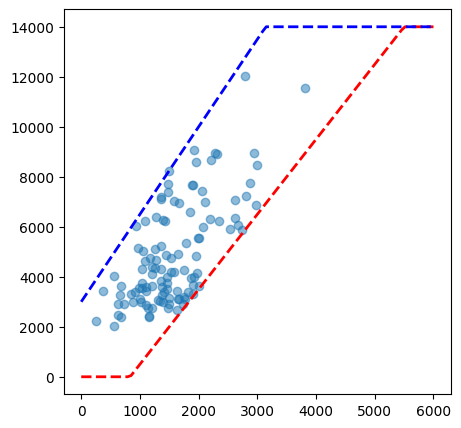

In [5]:
df_lfil = df_pred.loc[(df_pred[yfeat].values >  m*df_gt[df_gt["label ID"].isin(df_pred["soil_core"])][xfeat].values+b) & (df_pred[yfeat].values <  m2*df_gt[df_gt["label ID"].isin(df_pred["soil_core"])][xfeat].values+b2)]
# df_lfil = df_pred.loc[df_pred[yfeat].values <  (m2*df_gt[df_gt["label ID"].isin(df_pred["soil_core"])][xfeat].values+b2)]
selcores = df_lfil["soil_core"].values
df_gtselcores = df_gt[df_gt["label ID"].isin(selcores)]
df_gtselcores.reset_index(drop=True, inplace=True)
df_predselcores = df_pred[df_pred["soil_core"].isin(selcores)]
df_predselcores.reset_index(drop=True, inplace=True)

plt.figure(figsize=(5, 5))
plt.scatter(df_gtselcores[xfeat].values, df_predselcores[yfeat].values, alpha=0.5)
plt.plot(xl, yl, 'r--', linewidth=2)
plt.plot(xl, yl2, 'b--', linewidth=2)


In [6]:
selcores = list(selcores)

In [7]:
# save selcores as csv
df_selcores = pd.DataFrame({"sel_cores": selcores})
df_selcores.to_csv("data_info/sel_cores.csv", index=False)